[<img src="../../header.svg">](../index.ipynb)

---
# Finite Elements: Error analysis for the Poisson equation
The [previous section](./tutorial-fem-01.ipynb) introduced the key steps for discretizing the Poisson equation. 
We revisit this equation
$$\nabla \cdot[-D \nabla u] = f $$
with diffusion constant $D=1$ and source $f$ for different geometries in closer detail. The goal is to determine the discretization error. 



In [1]:

import sys
sys.path.append("..")

import modsimtools as util

import ug4py.pyugcore as ugcore
import ug4py.pyconvectiondiffusion as cd

import math  # For sqrt, sin, exp, ...

## Problem definitions

The problem definition is moved into classes.

### Problem 1

Die folgende Klasse kodiert das [vorherige Beispiel](./tutorial-fem-01.ipynb) zur Laplace-Gleichung ($D=1$). Dabei wird die rechte Seite $f$ wird so gesetzt, dass sich Sinusschwingung 

$$u(x,y) = \sin (\mu  \pi x) \sin (\nu  \pi y)$$

als Lösung ergibt. Außerdem diskretisieren wir das Einheitsquadrat mit Dreicken/Vierecken:

In [90]:
class SquareConfig:
    # Geometrie
    gridName= "grids/unit_square_quad.ugx" # "grids/unit_square_tri.ugx",
    requiredSubsets = {"Inner", "Boundary"}
    numRefs= 3
    
    # Constructor
    def __init__(self, mu, nu):
        self.mu = mu
        self.nu = nu
        
        self.elemDisc = cd.ConvectionDiffusionFE2d("u", "Inner")
        self.elemDisc.set_diffusion(1.0)
        self.elemDisc.set_source(ugcore.PythonUserNumber2d(lambda x,y,t,si : self.SourceCallback(x,y,t)))
        
        self.dirichletBND = ugcore.DirichletBoundary2dCPU1()
        self.dirichletBND.add(0.0, "u", "Boundary")
        
    
    # API function
    def CreateDomainDisc(self,approxSpace):   
        domainDisc = ugcore.DomainDiscretization2dCPU1(approxSpace)  
        domainDisc.add(self.elemDisc)
        domainDisc.add(self.dirichletBND)
        return domainDisc
    
    # Callback fuer rechte Seite
    def SourceCallback(self, x, y, t):
        mu = self.mu
        nu = self.nu
        scale =  (mu*mu + nu*nu)*(math.pi)*(math.pi)
        return scale*math.sin(math.pi*mu*x)* math.sin(math.pi*nu*y)

    # This is the exact solution.
    def SolutionCallback(self,x,y,t,si):
        return math.sin(math.pi*self.mu*x)* math.sin(math.pi*self.nu*y)


### Problem 2
This is an example of a circle with a nook ("einspringende Ecke"). The solution is not very regular.

In [118]:
class SectorProblem:
    # Geometrie
    gridName= "grids/sector_ref0.ugx"
    # gridName= "grids/sectorTest.ugx"
    
    requiredSubsets = {"Inner", "Circle", "Cut"}
    numRefs= 2
    
    # Constructor
    def __init__(self ,mu = 1.0, nu = 4.0):
        self.mu = mu
        self.nu = nu
        
        self.elemDisc = cd.ConvectionDiffusionFE2d("u", "Inner")
        self.elemDisc.set_diffusion(1.0)
        self.elemDisc.set_source(0.0)
    
        self.dirichletBND = ugcore.DirichletBoundary2dCPU1()
        self.dirichletBND.add(ugcore.PythonUserNumber2d(self.SolutionCallback), "u", "Circle")
        self.dirichletBND.add(0.0, "u", "Cut")
    
    # API function
    def CreateDomainDisc(self,approxSpace):   
        domainDisc = ugcore.DomainDiscretization2dCPU1(approxSpace)  
        domainDisc.add(self.elemDisc)
        domainDisc.add(self.dirichletBND)
        return domainDisc
    
    # This is the exact solution.
    def SolutionCallback(self,x,y,t,si):
        r = math.sqrt(x*x+y*y);
        phi = math.atan2(y,x);
        if (phi<0) : phi = phi + 2*math.pi; 
        val=math.pow(r,(2/3))*math.sin(phi/3.0*2);
        return val
    
   

### Problem selection
Select one of the problems:

In [119]:
#CONFIG = SquareConfig(1,3)
CONFIG = SectorProblem()

## Konfiguration von UG4

Die folgenden Schritte sind aus dem [vorherigen Beispiel](./tutorial-fem-01.ipynb) bekannt:


In [120]:
dom = util.CreateDomain(CONFIG.gridName, CONFIG.numRefs, CONFIG.requiredSubsets)
approxSpace = util.CreateApproximationSpace(dom, dict(fct = "u", type = "Lagrange", order = 1))
domainDisc = CONFIG.CreateDomainDisc(approxSpace)

Loading Domain 'grids/sector_ref0.ugx'...
Domain loaded.
Refining ...
Refining step {0} ...
Refining step {1} ...
Refining done


### Assemble and solve linear system 
Assemble as usual:

In [121]:
Ah = ugcore.AssembledLinearOperatorCPU1(domainDisc)
uh = ugcore.GridFunction2dCPU1(approxSpace)
bh = ugcore.GridFunction2dCPU1(approxSpace)

import traceback
try:
    domainDisc.assemble_linear(Ah, bh)
    domainDisc.adjust_solution(uh)
except Exception as inst:
    traceback.print_exc()
    print(str(inst))
    

Instead of an LU decomposition, use a **multigrid method** as a solver, which has linear complexity.

In [122]:
# solver = ugcore.LUCPU1()

In [123]:
sys.path.append("..")
import util.solver_util as util_solver

gmg = util_solver.CreateMultigridPrecond(approxSpace, domainDisc, "V",2,2)
gmg.set_discretization(domainDisc)

solver = ugcore.LinearSolverCPU1()
solver.set_preconditioner(gmg)
solver.set_convergence_check(util_solver.convCheck)

In [124]:
try:
    solver.init(Ah, uh)
    solver.apply(uh, bh)
except Exception as inst:
    traceback.print_exc()
    print(inst)
    

In [125]:
ugcore.WriteGridFunctionToVTK(uh, "fem02_solution_u")

In [138]:
try:
    import pyvista
    pyvista.set_jupyter_backend('static')
    # pyvista.start_xvfb()
    # pyvista.set_jupyter_backend('trame')
except Exception:
    pyvista=None

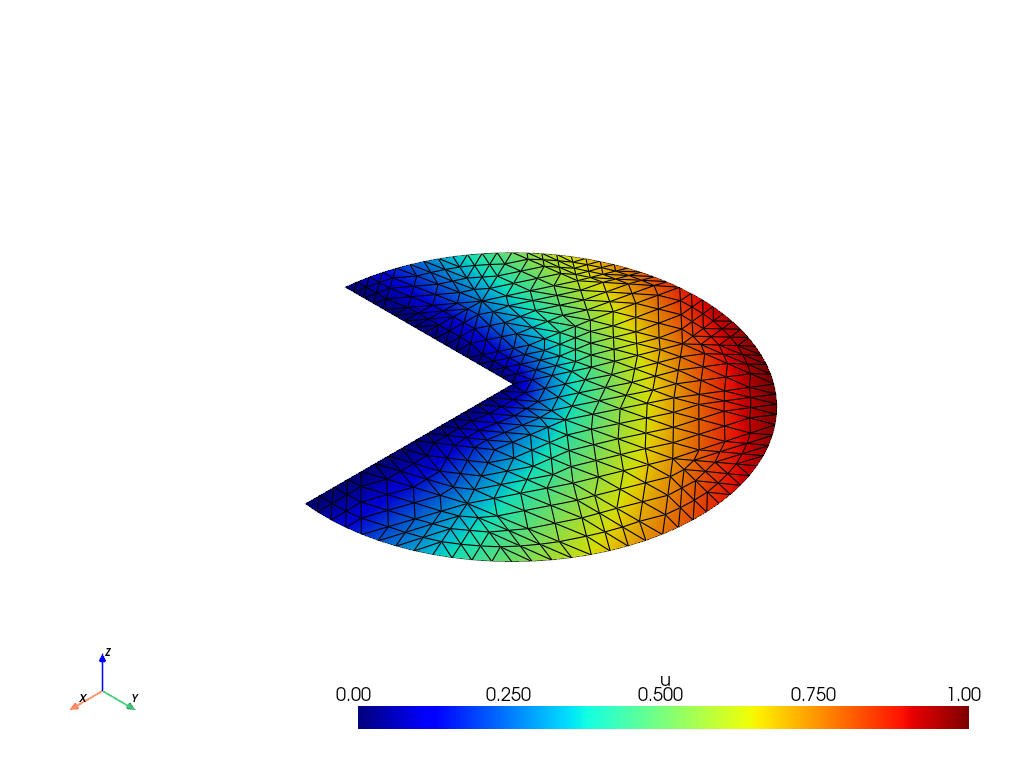

In [139]:
if pyvista is not None:
    result = pyvista.read("fem02_solution_u.vtu")
    result.plot(scalars="u", show_edges=True, cmap='jet')

## Error analysis

Falls die  Lösung analytisch bekannt ist, können wir den Diskretisierungsfehler der numerischen Lösung $u_h$ bestimmen.  

Dies geschieht in der L2-Norm: $$\|u-u_h\|_0 := \sqrt{\int_\Omega (u-u_h)^2 }$$

In [133]:
err0=ugcore.L2Error(ugcore.PythonUserNumber2d(CONFIG.SolutionCallback), uh, "u", 1.0, 4)
print(err0)

0.003029457752126185


 Alternativ kann die H1-Norm verwendet werden, welche auch Ableitungen berücksichtigt: $$\|u-u_h\|_1 := \sqrt{\int_\Omega (u-u_h)^2+ (\nabla (u-u_h))^2 }$$


In [134]:
uref = uh.clone()
ugcore.Interpolate(ugcore.PythonUserNumber2d(CONFIG.SolutionCallback), uref, "u")
err1=ugcore.H1Error(uref, "u",  uh, "u", 2, "Inner")
print(err1)


0.023142464491492567


We can visualize the error as well:

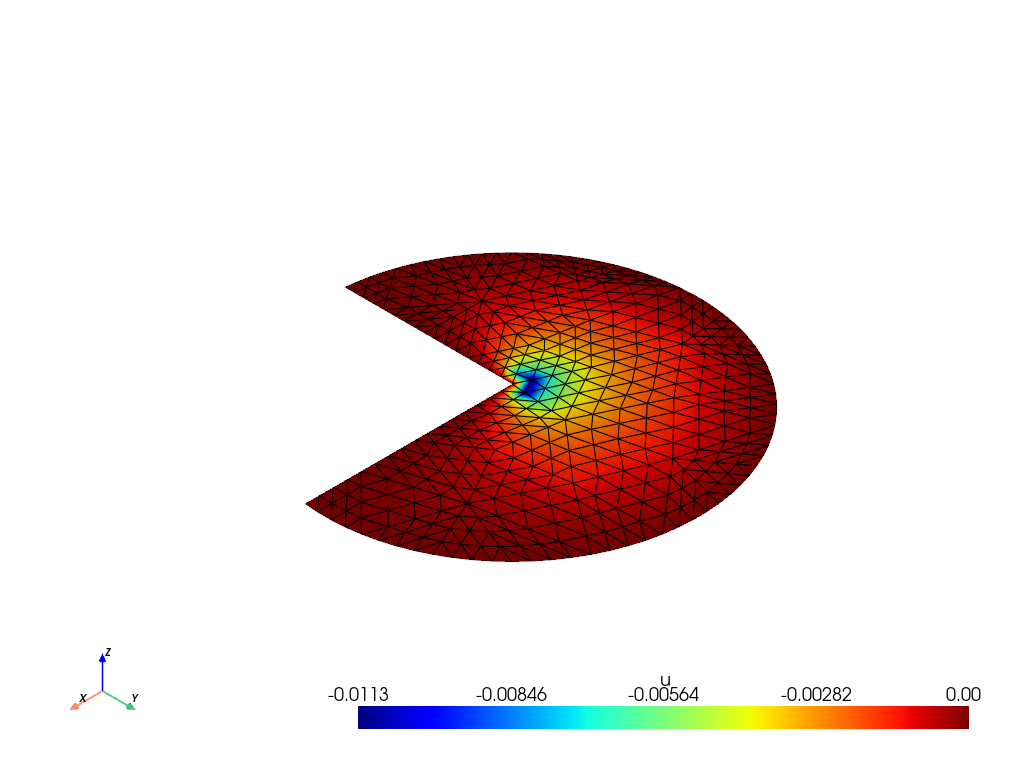

In [135]:
errh = uh.clone()
ugcore.VecScaleAdd2(errh, 1.0, uh, -1.0, uref)
ugcore.WriteGridFunctionToVTK(errh, "tmp/fem02_error")

if pyvista is not None:
    result = pyvista.read("tmp/fem02_error.vtu")
    result.plot(scalars="u", show_edges=True, cmap='jet')

Die Werte speichern wir in einer Tabelle:

In [113]:
import numpy as np
esquare=np.array([
    # numRefs, err0, err1
    [3, 0.026669178876216,0.036854207999089 ],
    [4, 0.0067063542743748,0.0096692527695234],
    [5, 0.0016790153921112,0.0024457630567399],
    [6, 0.00041990545869718,0.00061321594052763],
    [7, 0.0001049859512669,0.0001534133061914],
])


In [140]:
esector=np.array([
    # numRefs, err0, err1
    [3, 0.0021517562195368, 0.014347178579376 ],
    [4, 0.00082670975412983, 0.0090798283058054],
    [5, 0.00032006823581697, 0.0057306863871163],
    [6, 0.00013039000095758, 0.003629782236302],
    [7, 5.5487900630332e-05, 0.0022953491311963],
])


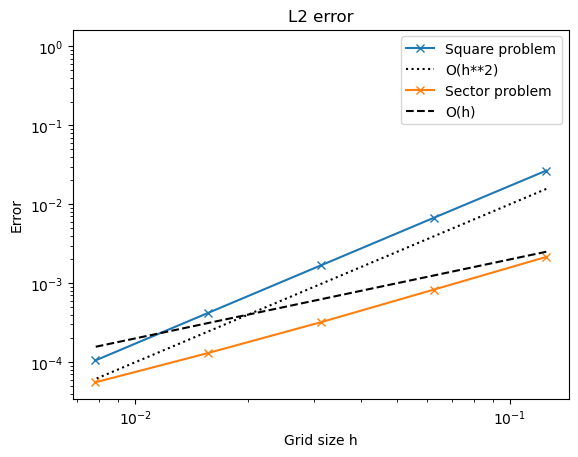

In [141]:
import matplotlib.pyplot as pyplot
pyplot.title("L2 error")
pyplot.xlabel("Grid size h")
pyplot.ylabel("Error")


pyplot.plot(0.5**(esquare[:,0]), esquare[:,1], label='Square problem', marker="x")
pyplot.plot(0.5**(esector[:,0]), (0.5**(esector[:,0]))**2, label='O(h**2)', linestyle='dotted', color='black')


pyplot.plot(0.5**(esector[:,0]), esector[:,1],  label='Sector problem', marker="x")
pyplot.plot(0.5**(esector[:,0]), 0.02*0.5**(esector[:,0]), label='O(h)', linestyle='dashed', color='black')

pyplot.legend()
pyplot.loglog(True)


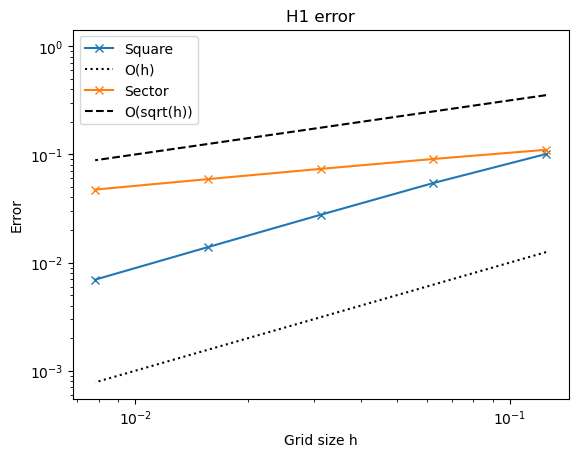

In [142]:
import matplotlib.pyplot as pyplot
pyplot.title("H1 error")
pyplot.xlabel("Grid size h")
pyplot.ylabel("Error")

h1semi_square = np.sqrt(esquare[:,2]- esquare[:,1])
h1semi_sector = np.sqrt(esector[:,2]- esector[:,1])

#pyplot.plot(0.5**(esquare[:,0]), esquare[:,2], label='Square', marker="x")
#pyplot.plot(0.5**(esector[:,0]), esector[:,2], label='Sector', marker="x")
pyplot.plot(0.5**(esector[:,0]), h1semi_square, label='Square', marker="x")
pyplot.plot(0.5**(esector[:,0]), 0.1*0.5**(esector[:,0]), label='O(h)', linestyle='dotted', color='black')

pyplot.plot(0.5**(esector[:,0]), h1semi_sector, label='Sector', marker="x")
pyplot.plot(0.5**(esector[:,0]), (0.5**(esector[:,0]))**0.5, label='O(sqrt(h))', linestyle='dashed', color='black')


pyplot.legend()
pyplot.loglog(True)